<a href="https://colab.research.google.com/github/beingAnujChaudhary/DSFS-Joel-Grus/blob/main/notebooks/chapter_03_visualizing_data/03_visualizing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Mount Google Drive (optional)
drive.mount('/content/drive')

# Clone your GitHub repository
!git clone https://github.com/beingAnujChaudhary/DSFS-Joel-Grus.git

# Move into repository
%cd /content/DSFS-Joel-Grus

# Move into Chapter 1 folder
%cd notebooks/chapter_03_visualizing_data

Mounted at /content/drive
Cloning into 'DSFS-Joel-Grus'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 162 (delta 106), reused 92 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 890.48 KiB | 3.41 MiB/s, done.
Resolving deltas: 100% (106/106), done.
/content/DSFS-Joel-Grus
/content/DSFS-Joel-Grus/notebooks/chapter_03_visualizing_data


---

# Chapter 3: Visualizing Data

**Book**: *Data Science from Scratch* by Joel Grus  
**Focus**: Creating clear, honest visualizations using `matplotlib.pyplot`

## Purpose

This notebook contains my implementation and understanding of Chapter 3. We'll learn to create:
- **Bar charts**: For comparing quantities across categories or bucketed values
- **Line charts**: For showing trends over ordered sequences
- **Scatterplots**: For visualizing relationships between paired variables

> 💡 **Key principle**: A chart is not just a picture—it's an argument. Always prioritize honest representation over visual flair.

### Learning Objectives

By the end of this chapter, I should understand:
- Why visualization matters before analysis or modelling
- How to create charts using `matplotlib.pyplot`
- Different chart types and when to use each one
- How to interpret visualizations and spot patterns
- Common visualization mistakes and how to avoid them
- Best practices for clear, honest data communication

---

## Environment Setup


In [2]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Set style for cleaner charts
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Chapter 3 environment ready!")
print(f"matplotlib version: {plt.matplotlib.__version__}")

✅ Chapter 3 environment ready!
matplotlib version: 3.10.0


---

## 1. matplotlib.pyplot Basics

`matplotlib.pyplot` maintains an internal state to build visualizations step-by-step.

**Basic workflow:**
1. Create chart with `plt.plot()`, `plt.bar()`, or `plt.scatter()`
2. Customize with labels, titles, legends, and formatting
3. Display with `plt.show()` or save with `plt.savefig()`

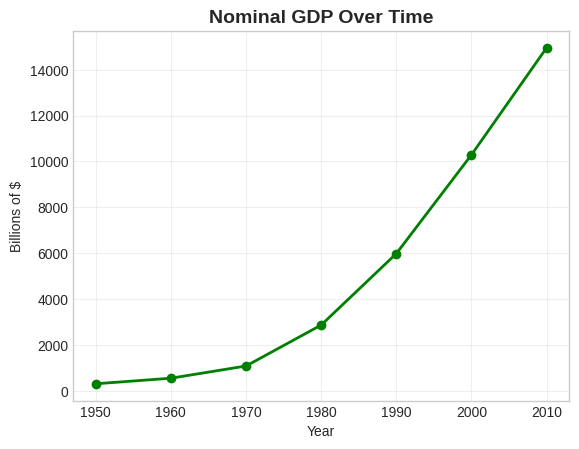

In [3]:
# Simple Line Chart Example
years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
gdp = [300.2, 543.3, 1075.9, 2862.5, 5979.6, 10289.7, 14958.3]

# Create line chart
plt.plot(years, gdp, color='green', marker='o', linestyle='solid', linewidth=2)

# Add labels and title
plt.title("Nominal GDP Over Time", fontsize=14, fontweight='bold')
plt.ylabel("Billions of $")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)

# Display
plt.show()

# Optional: Save to file
# plt.savefig("gdp_chart.png", dpi=300, bbox_inches='tight')

**Interpretation questions:**
- Is GDP increasing over time?
- Is growth linear or exponential?
- Are there any unusual jumps or dips?

---

## 2. Line Charts

Line charts excel at showing **trends over ordered data** (time, sequence, model complexity, etc.).

### Example: Company Revenue Over Time

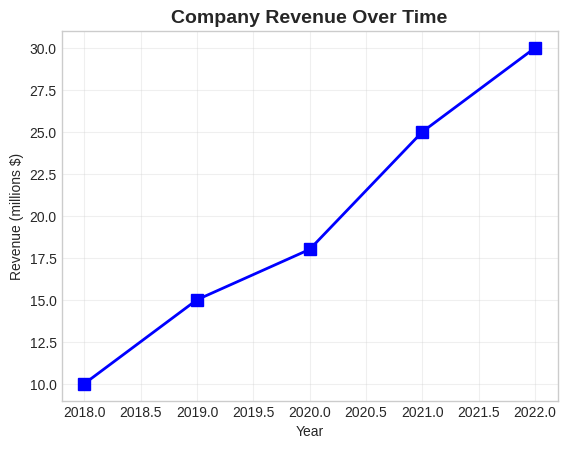

In [4]:
years = [2018, 2019, 2020, 2021, 2022]
revenue = [10, 15, 18, 25, 30]

plt.plot(years, revenue, marker='s', color='blue', linewidth=2, markersize=8)

plt.title("Company Revenue Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Revenue (millions $)")
plt.grid(True, alpha=0.3)

plt.show()

### Example: The Bias-Variance Tradeoff


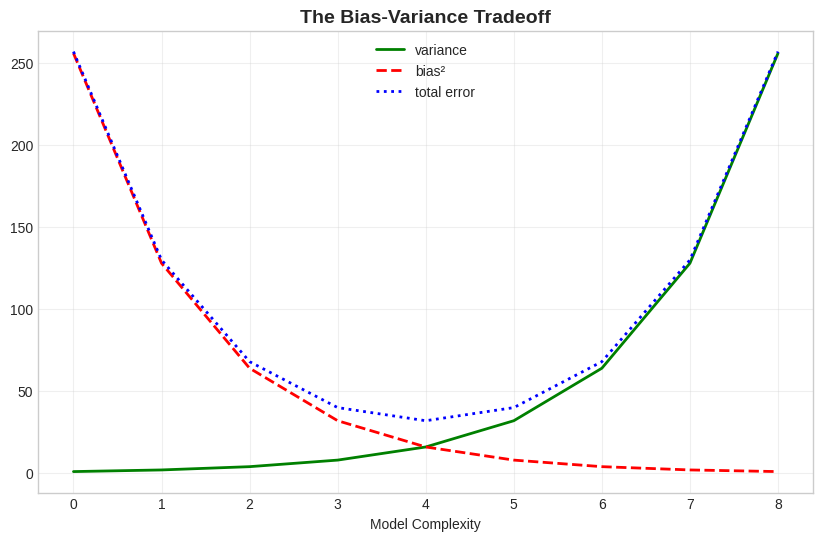

In [5]:
variance = [1, 2, 4, 8, 16, 32, 64, 128, 256]
bias_squared = [256, 128, 64, 32, 16, 8, 4, 2, 1]
total_error = [x + y for x, y in zip(variance, bias_squared)]
xs = range(len(variance))

# Plot multiple series with different styles
plt.figure(figsize=(10, 6))
plt.plot(xs, variance, 'g-', label='variance', linewidth=2)      # green solid
plt.plot(xs, bias_squared, 'r--', label='bias²', linewidth=2)    # red dashed
plt.plot(xs, total_error, 'b:', label='total error', linewidth=2) # blue dotted

# Add legend and labels
plt.legend(loc='best')
plt.xlabel("Model Complexity")
plt.xticks(xs)
plt.title("The Bias-Variance Tradeoff", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation questions:**
- Which grows faster — variance or bias?
- Where is total error minimized?
- Why does this matter for model selection?

### Style Codes Reference

| Code | Line Style | Code | Color |
|------|-----------|------|-------|
| `'-'` | solid | `'r'` | red |
| `'--'` | dashed | `'g'` | green |
| `'-.'` | dot-dash | `'b'` | blue |
| `':'` | dotted | `'k'` | black |

---

## 3. Bar Charts

Bar charts are ideal for **comparing quantities across discrete categories**.

### Example: Programming Language Popularity


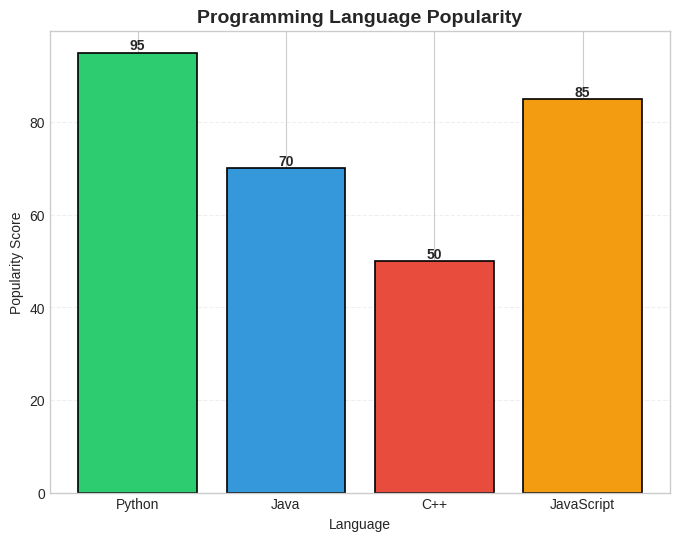

In [6]:
languages = ["Python", "Java", "C++", "JavaScript"]
popularity = [95, 70, 50, 85]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

plt.figure(figsize=(8, 6))
bars = plt.bar(languages, popularity, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             str(height), ha='center', va='bottom', fontweight='bold')

plt.title("Programming Language Popularity", fontsize=14, fontweight='bold')
plt.xlabel("Language")
plt.ylabel("Popularity Score")
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.show()

**Interpretation questions:**
- Which language has the highest popularity score?
- How large are the differences between languages?
- Are the comparisons visually clear?

### Example: Academy Awards by Movie


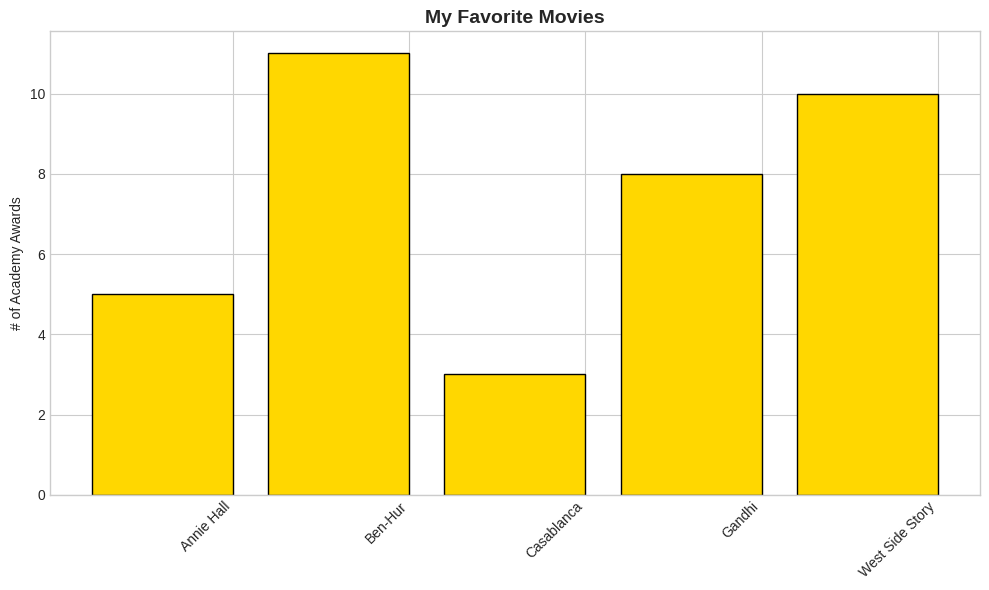

In [7]:
movies = ["Annie Hall", "Ben-Hur", "Casablanca", "Gandhi", "West Side Story"]
num_oscars = [5, 11, 3, 8, 10]

# Center bars by offsetting x-coordinates (bars default to width 0.8)
xs = [i + 0.1 for i, _ in enumerate(movies)]

# Plot bars
plt.figure(figsize=(10, 6))
plt.bar(xs, num_oscars, color='gold', edgecolor='black')

# Label x-axis with movie names at bar centers
plt.xticks([i + 0.5 for i, _ in enumerate(movies)], movies, rotation=45, ha='right')

plt.ylabel("# of Academy Awards")
plt.title("My Favorite Movies", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Histograms (Bar Charts for Distributions)

Histograms show **data distribution** by bucketing numeric values.

### Example: Distribution of Exam Scores


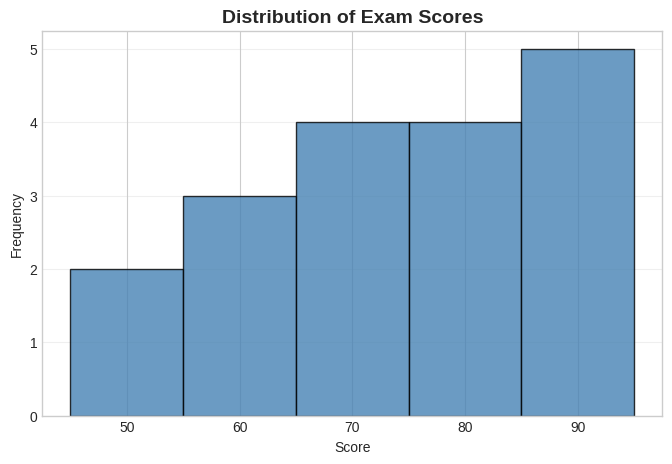

In [8]:
exam_scores = [45, 50, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92, 95]

plt.figure(figsize=(8, 5))
plt.hist(exam_scores, bins=5, color='steelblue', edgecolor='black', alpha=0.8)

plt.title("Distribution of Exam Scores", fontsize=14, fontweight='bold')
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

### Example: Exam Grades by Decile (Manual Bucketing)



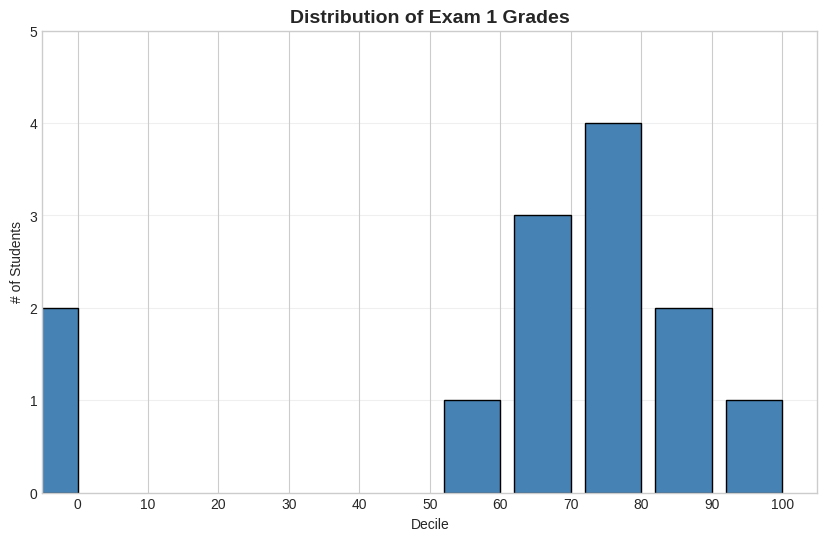

In [9]:
grades = [83, 95, 91, 87, 70, 0, 85, 82, 100, 67, 73, 77, 0]

# Bucket grades by decile
decile = lambda grade: grade // 10 * 10
histogram = Counter(decile(grade) for grade in grades)

# Plot histogram
# Shift bars left by 4 so bucket "80" spans 76-84 (center at 80)
plt.figure(figsize=(10, 6))
plt.bar([x - 4 for x in histogram.keys()], histogram.values(),
        width=8, edgecolor='black', color='steelblue')

# Customize axes
plt.axis([-5, 105, 0, 5])  # x: -5 to 105, y: 0 to 5
plt.xticks([10 * i for i in range(11)])  # Labels at 0, 10, ..., 100

plt.xlabel("Decile")
plt.ylabel("# of Students")
plt.title("Distribution of Exam 1 Grades", fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Interpretation questions:**
- Is the distribution balanced or skewed?
- Where do most scores cluster?
- Are there any outliers?

---

## 5. Scatter Plots

Scatter plots visualize **relationships between two paired variables**.

### Example: Hours Studied vs Marks


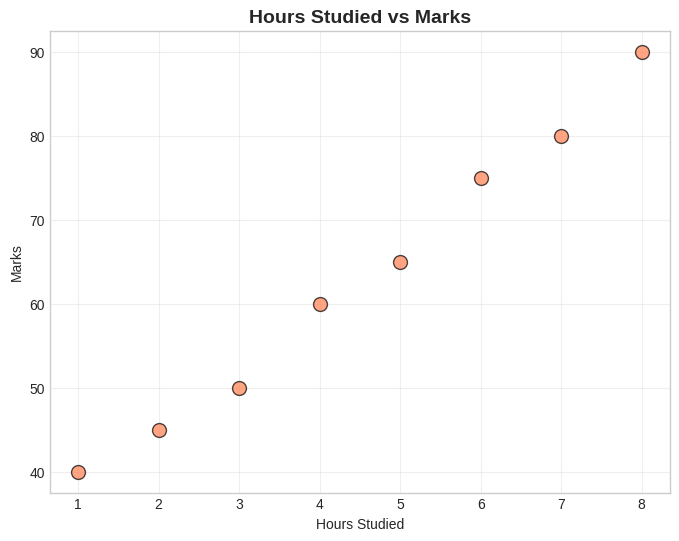

In [10]:
ours_studied = [1, 2, 3, 4, 5, 6, 7, 8]
marks = [40, 45, 50, 60, 65, 75, 80, 90]

plt.figure(figsize=(8, 6))
plt.scatter(hours_studied, marks, s=100, alpha=0.7, edgecolors='black', color='coral')

plt.title("Hours Studied vs Marks", fontsize=14, fontweight='bold')
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretation questions:**
- Is there a correlation between hours and marks?
- Is the relationship linear?
- Are there any unusual data points?

### Example: Daily Minutes vs Number of Friends (with Annotations)


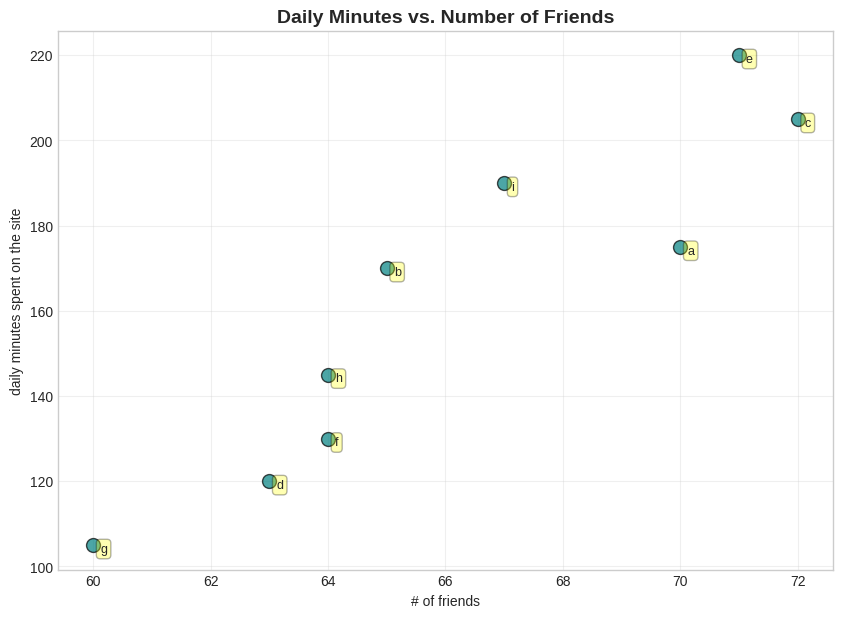

In [11]:
friends = [70, 65, 72, 63, 71, 64, 60, 64, 67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

plt.figure(figsize=(10, 7))
plt.scatter(friends, minutes, s=100, alpha=0.7, edgecolors='black', color='teal')

# Annotate each point
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(label,
                 xy=(friend_count, minute_count),  # Point to label
                 xytext=(5, -5),                    # Offset text
                 textcoords='offset points',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.title("Daily Minutes vs. Number of Friends", fontsize=14, fontweight='bold')
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on the site")
plt.grid(True, alpha=0.3)
plt.show()

---

## 6. Visualization Mistakes & How to Avoid Them

### ⚠️ Misleading Y-Axis

**Never truncate the y-axis on bar charts**—it misleads viewers about magnitude differences.


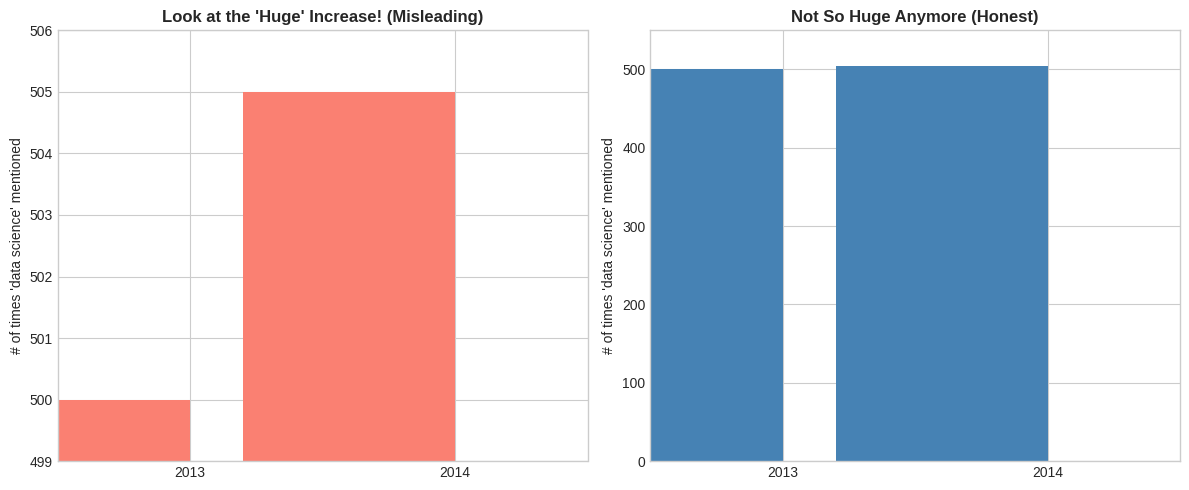

In [12]:
mentions = [500, 505]
years = [2013, 2014]

plt.figure(figsize=(12, 5))

# ❌ Misleading: y-axis starts at 499 (exaggerates small change)
plt.subplot(1, 2, 1)
plt.bar([2012.6, 2013.6], mentions, width=0.8, color='salmon')
plt.xticks(years)
plt.ylabel("# of times 'data science' mentioned")
plt.ticklabel_format(useOffset=False)
plt.axis([2012.5, 2014.5, 499, 506])  # Truncated y-axis
plt.title("Look at the 'Huge' Increase! (Misleading)", fontweight='bold')

# ✅ Honest: y-axis starts at 0 (shows true scale)
plt.subplot(1, 2, 2)
plt.bar([2012.6, 2013.6], mentions, width=0.8, color='steelblue')
plt.xticks(years)
plt.ylabel("# of times 'data science' mentioned")
plt.ticklabel_format(useOffset=False)
plt.axis([2012.5, 2014.5, 0, 550])  # Full y-axis from 0
plt.title("Not So Huge Anymore (Honest)", fontweight='bold')

plt.tight_layout()
plt.show()

### ⚠️ Unequal Axes for Comparable Variables

When plotting comparable variables, use `plt.axis("equal")`:

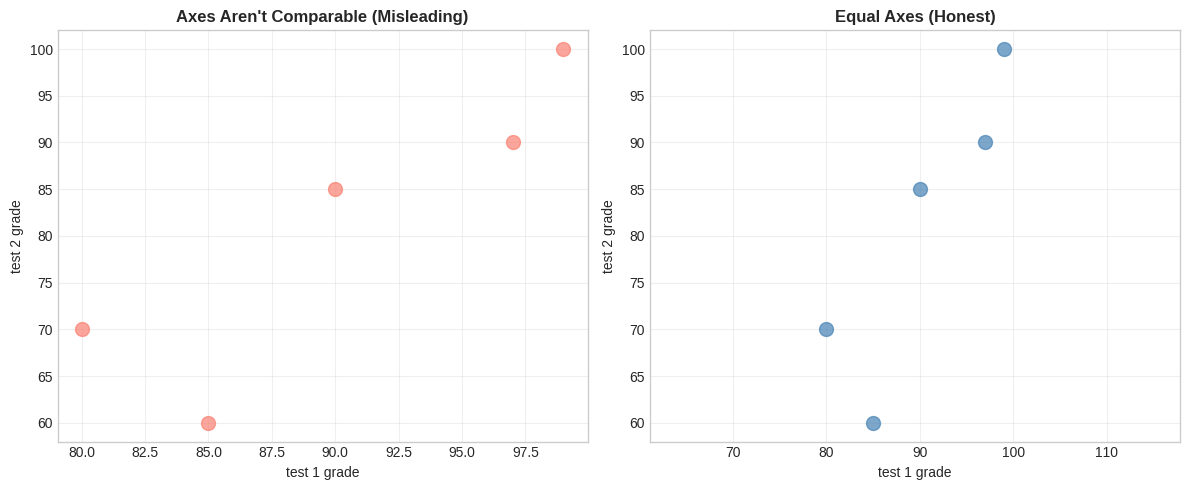

In [13]:
test_1_grades = [99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

plt.figure(figsize=(12, 5))

# Without equal axes: variation appears balanced (misleading)
plt.subplot(1, 2, 1)
plt.scatter(test_1_grades, test_2_grades, s=100, alpha=0.7, color='salmon')
plt.title("Axes Aren't Comparable (Misleading)", fontweight='bold')
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.grid(True, alpha=0.3)

# With equal axes: true variation is visible (honest)
plt.subplot(1, 2, 2)
plt.scatter(test_1_grades, test_2_grades, s=100, alpha=0.7, color='steelblue')
plt.axis("equal")  # Same scale on both axes
plt.title("Equal Axes (Honest)", fontweight='bold')
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Example: Potentially Misleading Scale


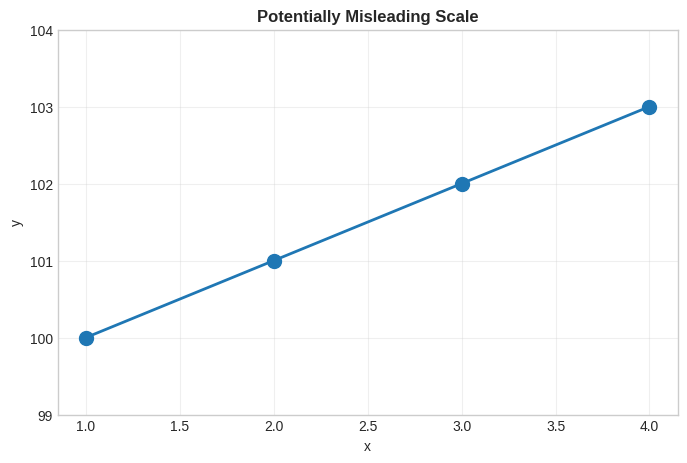

In [14]:
x = [1, 2, 3, 4]
y = [100, 101, 102, 103]

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linewidth=2, markersize=10)
plt.ylim(99, 104)  # Deliberately narrow y-axis range
plt.title("Potentially Misleading Scale", fontweight='bold')
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

**Reflection:** Why does this graph exaggerate changes? When might this be intentional vs. deceptive?

---

## 7. Multiple Plots Comparison


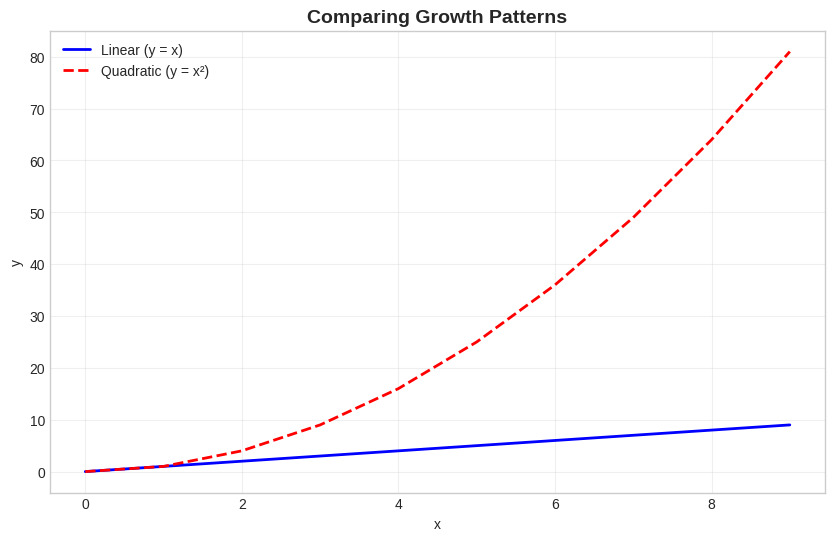

In [15]:
x = np.arange(0, 10, 1)

plt.figure(figsize=(10, 6))
plt.plot(x, x, 'b-', label="Linear (y = x)", linewidth=2)
plt.plot(x, x**2, 'r--', label="Quadratic (y = x²)", linewidth=2)

plt.title("Comparing Growth Patterns", fontsize=14, fontweight='bold')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


**Interpretation questions:**
- Which function grows faster as x increases?
- Why is it valuable to visualize mathematical functions?
- How does this apply to understanding algorithm complexity?

---

## 8. Putting It All Together — A Polished Chart


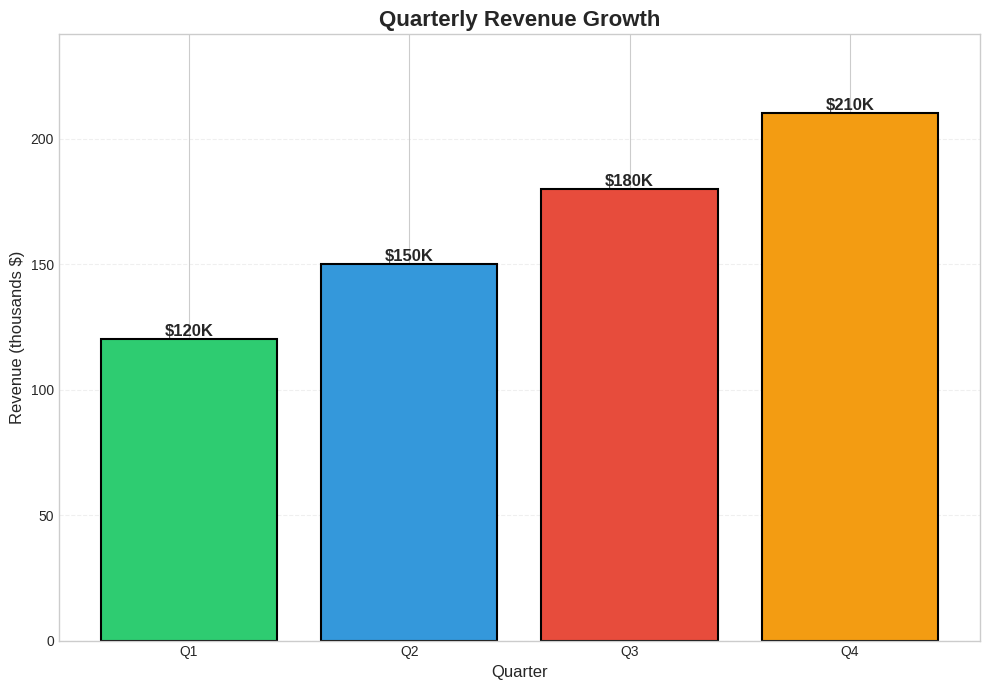

In [16]:
# Professional-looking bar chart with all best practices
categories = ['Q1', 'Q2', 'Q3', 'Q4']
revenue = [120, 150, 180, 210]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

plt.figure(figsize=(10, 7))
bars = plt.bar(categories, revenue, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height}K', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Customize appearance
plt.title("Quarterly Revenue Growth", fontsize=16, fontweight='bold')
plt.ylabel("Revenue (thousands $)", fontsize=12)
plt.xlabel("Quarter", fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, max(revenue) * 1.15)  # Leave room for labels
plt.tight_layout()
plt.show()

---

## 9. Customization Essentials Reference

| Function | Purpose | Example |
|----------|---------|---------|
| `plt.title()` | Add chart title | `plt.title("Sales Trend", fontsize=14)` |
| `plt.xlabel()` / `plt.ylabel()` | Label axes | `plt.xlabel("Month")` |
| `plt.legend()` | Add legend | `plt.legend(loc='best')` |
| `plt.xticks()` / `plt.yticks()` | Customize tick labels | `plt.xticks([0,1,2], ['A','B','C'])` |
| `plt.axis()` | Set axis limits | `plt.axis([0, 10, 0, 100])` |
| `plt.grid()` | Add grid lines | `plt.grid(True, alpha=0.3)` |
| `plt.annotate()` | Add text annotations | `plt.annotate('peak', xy=(5, 10))` |
| `plt.savefig()` | Export to file | `plt.savefig("chart.png", dpi=300)` |
| `plt.tight_layout()` | Prevent label cutoff | `plt.tight_layout()` |
| `plt.figure()` | Set figure size | `plt.figure(figsize=(10, 6))` |

**Pro tips:**
- Use `dpi=300` for publication-quality exports
- Use `bbox_inches='tight'` to trim whitespace when saving
- Use `alpha` for transparency in overlapping points
- Use `edgecolors` to make scatter points pop
- Test for colorblind accessibility using tools like [ColorBrewer](https://colorbrewer2.org)

---

## 🎯 Chapter 3 Summary

### Chart Type Selection Guide

| Question Type | Best Chart | Example |
|--------------|-----------|---------|
| Compare categories | Bar chart | Programming language popularity |
| Show distribution | Histogram | Exam score distribution |
| Show trend over time | Line chart | Revenue growth, GDP trends |
| Show relationship between variables | Scatter plot | Hours studied vs marks |
| Compare similar scales | Scatter plot with `axis("equal")` | Test scores comparison |

### Visualization Best Practices

✅ **DO:**
- Start y-axis at 0 for bar charts
- Use clear titles and axis labels
- Choose appropriate chart types for your question
- Keep designs simple and uncluttered
- Use `axis("equal")` for comparable variables

❌ **AVOID:**
- Misleading axes that exaggerate changes
- Too many colors or decorative elements
- Overcrowded visuals with too much information
- Wrong chart types for your data
- Omitting labels or legends

### matplotlib Workflow

```python
# 1. Create the chart
plt.plot(x, y)  # or plt.bar(), plt.scatter()

# 2. Customize
plt.title("Title")
plt.xlabel("X-axis label")
plt.ylabel("Y-axis label")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# 3. Finalize
plt.tight_layout()
plt.show()
# OR: plt.savefig("chart.png", dpi=300, bbox_inches='tight')
```

---

## 📝 Reflection

### Key Takeaways
- Different plots answer different questions — choose carefully
- Visualization reveals hidden patterns that raw numbers obscure
- Always understand data visually before building models
- Scatter plots are essential for exploring relationships
- Histograms help understand distributions and detect outliers

### Connection to Machine Learning
Visualization helps with:
- **Exploratory Data Analysis (EDA)** — understanding data before modelling
- **Feature engineering** — identifying useful transformations
- **Outlier detection** — spotting anomalous data points
- **Model debugging** — diagnosing overfitting and performance issues
- **Communication** — explaining findings to stakeholders

### Important Workflow Habit
After every chart you create, pause and ask:

> **What pattern do I see?**  
> **What story does this tell?**  
> **What could be misleading?**  
> **What question should I ask next?**

This habit becomes invaluable in EDA, feature engineering, model debugging, and production ML — because strong ML engineers interpret data, not just plot it.

---
